In [88]:
import numpy as np # Linear algebra
import pandas as pd # data processing
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [89]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tawfikelmetwally/wine-dataset")

print("Path to dataset files:", path)

import os

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "Wine dataset.csv"))
df.sample(5)

Using Colab cache for faster access to the 'wine-dataset' dataset.
Path to dataset files: /kaggle/input/wine-dataset
['Wine dataset.csv']


,class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
139,3,12.84,2.96,2.61,24.0,101,2.32,0.60,0.53,0.81,4.92,0.89,2.15,590
86,2,12.16,1.61,2.31,22.8,90,1.78,1.69,0.43,1.56,2.45,1.33,2.26,495
165,3,13.73,4.36,2.26,22.5,88,1.28,0.47,0.52,1.15,6.62,0.78,1.75,520
106,2,12.25,1.73,2.12,19.0,80,1.65,2.03,0.37,1.63,3.40,1.00,3.17,510
36,1,13.28,1.64,2.84,15.5,110,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880


In [90]:
df = df[[ 'class','Alcohol','Malic acid']]
df.sample(5)

,class,Alcohol,Malic acid
131,3,12.88,2.99
130,3,12.86,1.35
75,2,11.66,1.88
27,1,13.30,1.72
143,3,13.62,4.95


In [91]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(df.drop('class',axis=1),df['class'],test_size=0.3,random_state=0)

X_train.shape, X_test.shape

((124, 2), (54, 2))

# 1. MinMax Scaling

In [92]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

# fit the scaler to the train set, it will learn the parameters
scaler.fit(X_train)

# transform train and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [93]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns= X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)


## The values in data are scaled to values between range [0,1]

In [94]:
# Before Scaling
np.round(X_train.describe(), 1)

,Alcohol,Malic acid
count,124.0,124.0
mean,13.0,2.4
std,0.8,1.1
min,11.0,0.9
25%,12.4,1.6
50%,13.0,1.9
75%,13.6,3.2
max,14.8,5.6


In [95]:
# After Scaling
np.round(X_train_scaled.describe(),1)

,Alcohol,Malic acid
count,124.0,124.0
mean,0.5,0.3
std,0.2,0.2
min,0.0,0.0
25%,0.4,0.2
50%,0.5,0.2
75%,0.7,0.5
max,1.0,1.0


## Histogram

array([[<Axes: title={'center': 'Alcohol'}>,
        <Axes: title={'center': 'Malic acid'}>]], dtype=object)

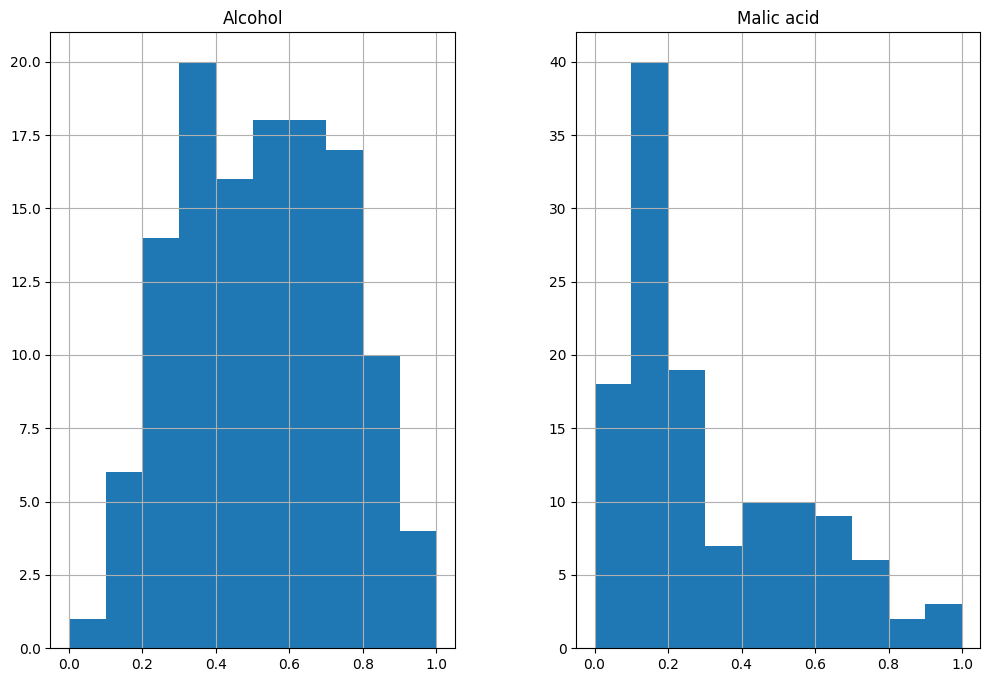

In [96]:
X_train_scaled.hist(figsize=(12, 8))

## Boxplot

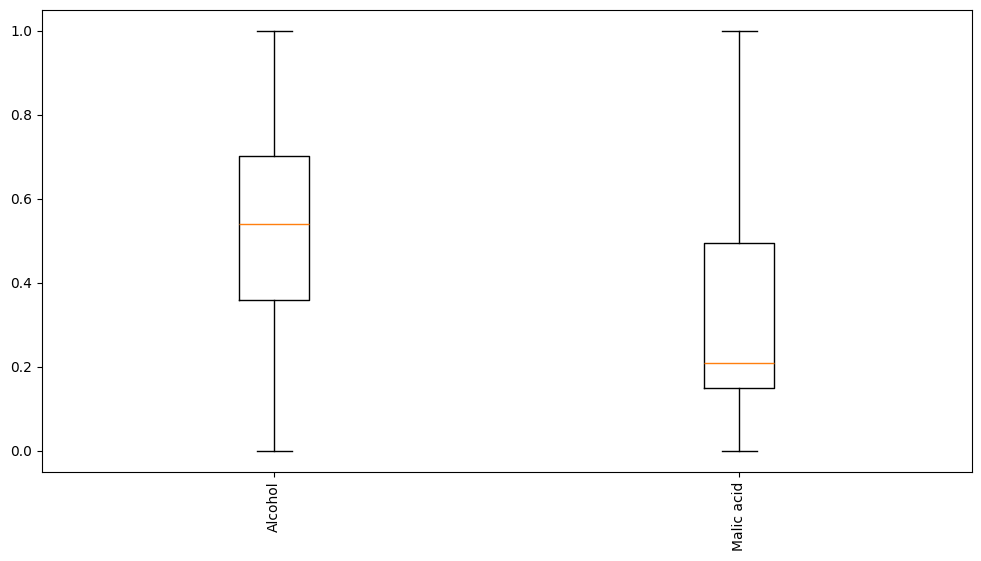

In [97]:

plt.figure(figsize=(12, 6))
plt.boxplot(X_train_scaled)
plt.xticks(range(1, len(X_train_scaled.columns) + 1), X_train_scaled.columns, rotation=90)
plt.show()

## Scatter plot

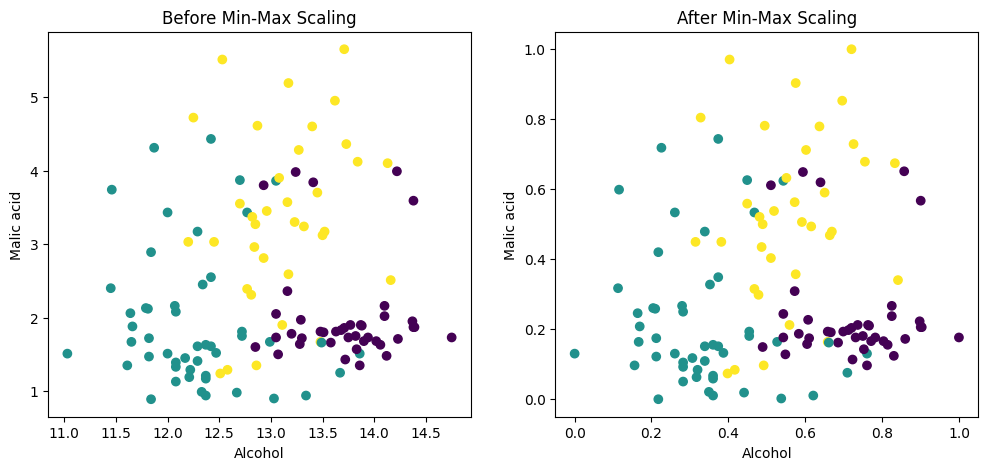

In [98]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before scaling
ax1.scatter(X_train['Alcohol'], X_train['Malic acid'], c=y_train)
ax1.set_title("Before Min-Max Scaling")
ax1.set_xlabel("Alcohol")
ax1.set_ylabel("Malic acid")

# After scaling
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic acid'], c=y_train)
ax2.set_title("After Min-Max Scaling")
ax2.set_xlabel("Alcohol")
ax2.set_ylabel("Malic acid")

plt.show()

## Pairplot

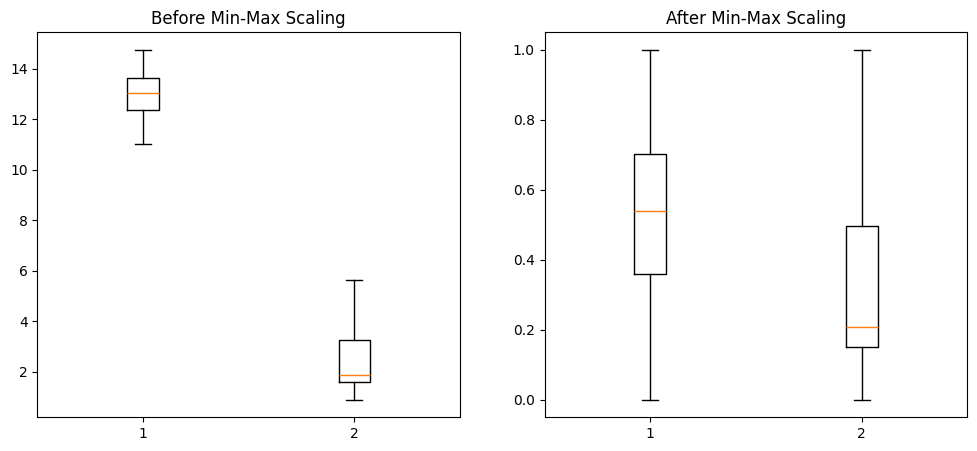

In [99]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.boxplot(X_train.values)
ax1.set_title("Before Min-Max Scaling")

ax2.boxplot(X_train_scaled.values)
ax2.set_title("After Min-Max Scaling")

plt.show()

## KDE (Kernel Density Estimate)

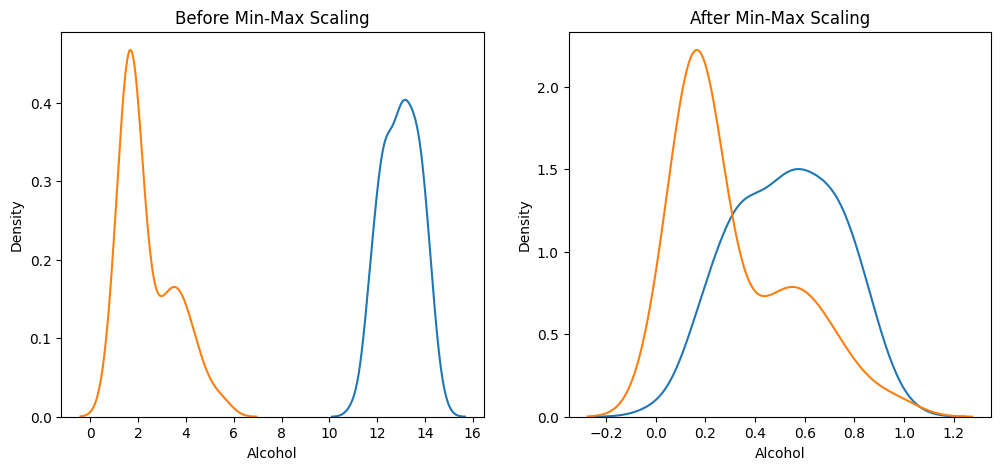

In [100]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Min-Max Scaling
ax1.set_title("Before Min-Max Scaling")
sns.kdeplot(X_train['Alcohol'], ax=ax1)
sns.kdeplot(X_train['Malic acid'], ax=ax1)
# After Min-Max Scaling
ax2.set_title("After Min-Max Scaling")
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2)
sns.kdeplot(X_train_scaled['Malic acid'], ax=ax2)

plt.show()

# 2. Mean Normalization

Not used Much

No dedicated library in Sklearn

Instead Standardization is used

# 3. Max Absolute Scaling

In [101]:
from sklearn.preprocessing import MaxAbsScaler
scaler = MaxAbsScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [102]:

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

## a. KDE
Compare distribution

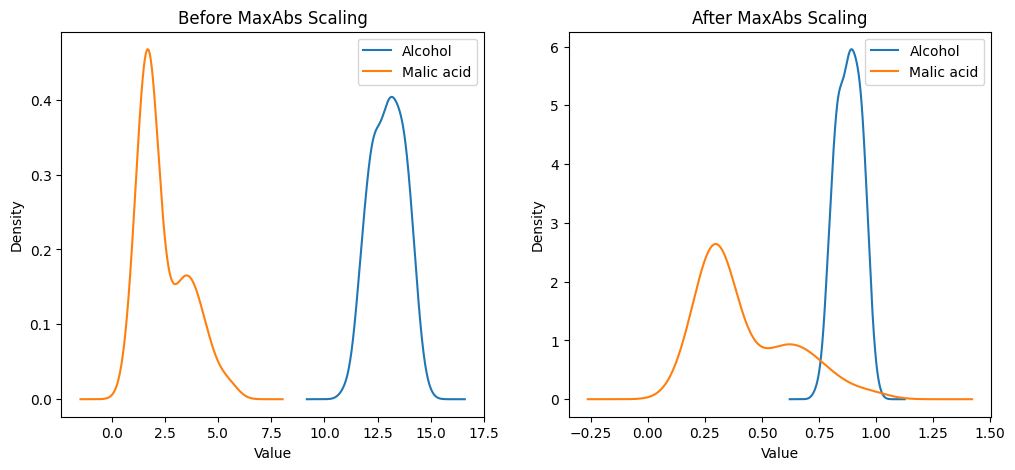

In [103]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before MaxAbs Scaling
X_train[['Alcohol', 'Malic acid']].plot(
    kind='kde',
    ax=ax1
)
ax1.set_title("Before MaxAbs Scaling")
ax1.set_xlabel("Value")

# After MaxAbs Scaling
X_train_scaled[['Alcohol', 'Malic acid']].plot(
    kind='kde',
    ax=ax2
)
ax2.set_title("After MaxAbs Scaling")
ax2.set_xlabel("Value")

plt.show()

## b. Boxplot
Compare scale + outliers

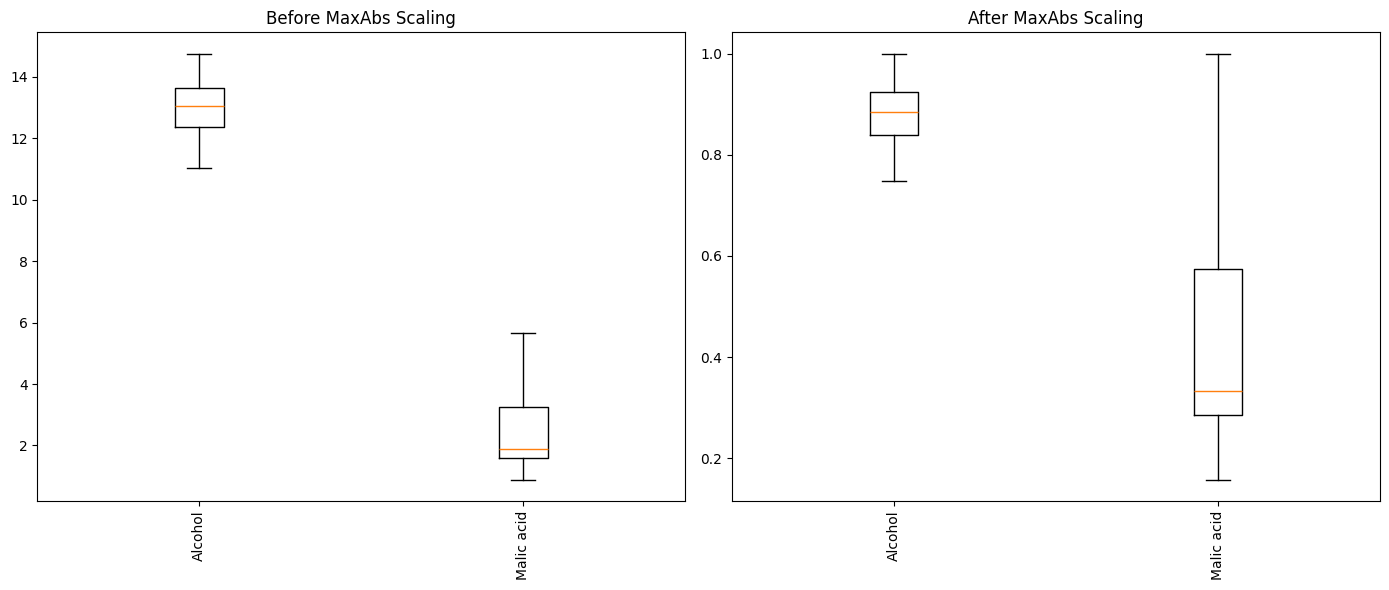

In [104]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6))

# Before scaling
ax1.boxplot(X_train.values)
ax1.set_title("Before MaxAbs Scaling")
ax1.set_xticks(range(1, len(X_train.columns) + 1))
ax1.set_xticklabels(X_train.columns, rotation=90)

# After scaling
ax2.boxplot(X_train_scaled.values)
ax2.set_title("After MaxAbs Scaling")
ax2.set_xticks(range(1, len(X_train_scaled.columns) + 1))
ax2.set_xticklabels(X_train_scaled.columns, rotation=90)

plt.tight_layout()
plt.show()

## c. Scatter
Compare relationship between features

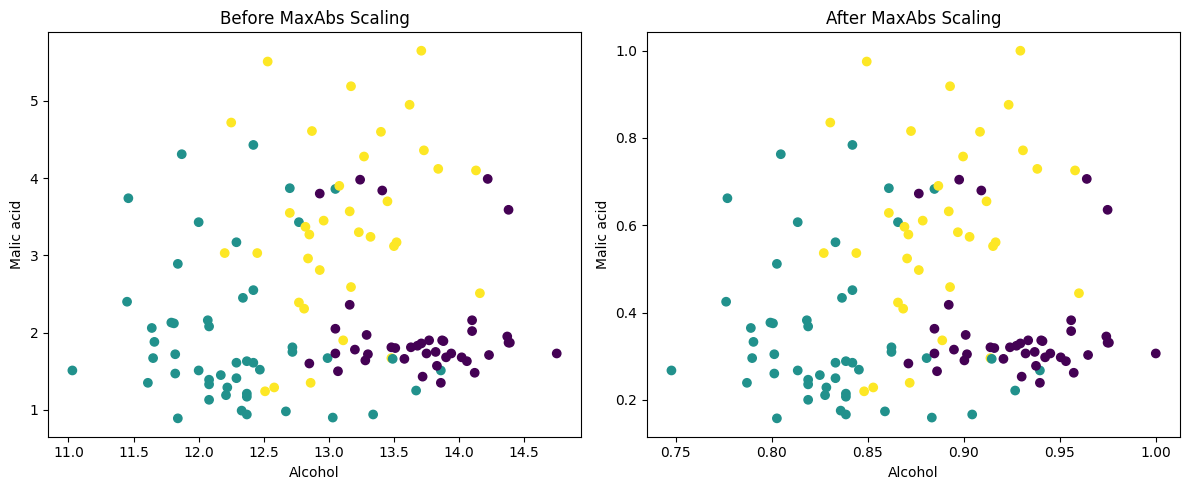

In [105]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before
ax1.scatter(
    X_train['Alcohol'],
    X_train['Malic acid'],
    c=y_train
)
ax1.set_title("Before MaxAbs Scaling")
ax1.set_xlabel("Alcohol")
ax1.set_ylabel("Malic acid")

# After
ax2.scatter(
    X_train_scaled['Alcohol'],
    X_train_scaled['Malic acid'],
    c=y_train
)
ax2.set_title("After MaxAbs Scaling")
ax2.set_xlabel("Alcohol")
ax2.set_ylabel("Malic acid")

plt.tight_layout()
plt.show()

# 4. Robust Scaling

In [106]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [107]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns
)

## a. Boxplot

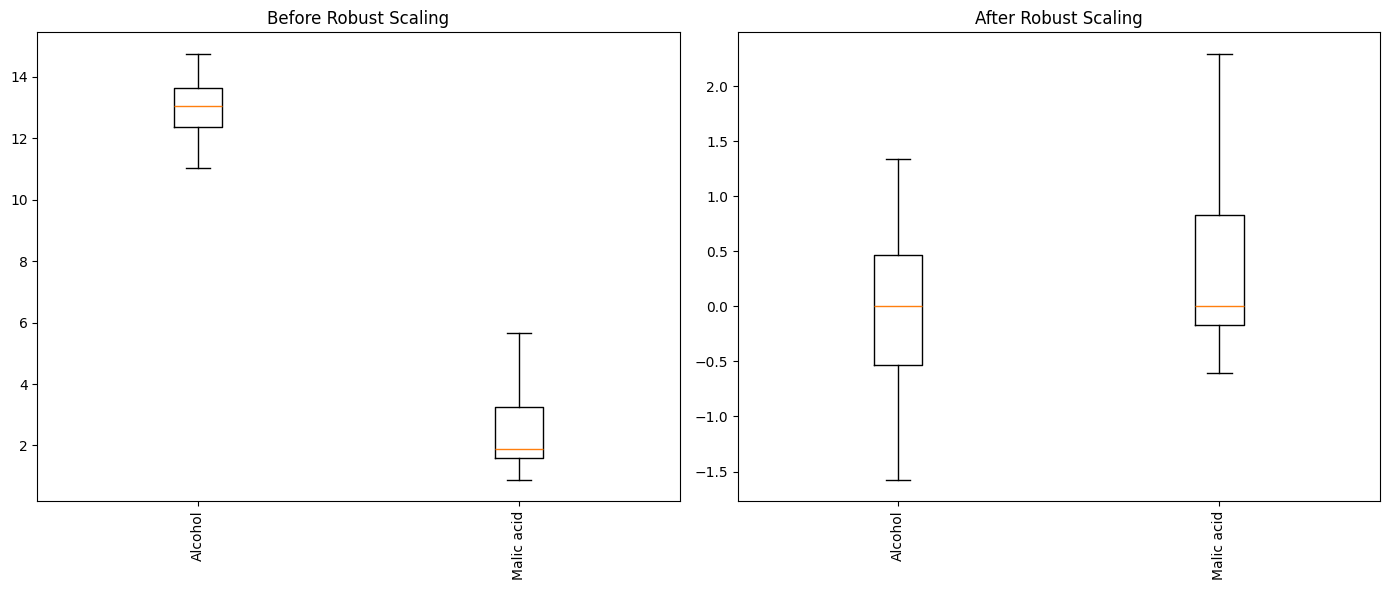

In [108]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(14, 6))

# Before scaling
ax1.boxplot(X_train.values)
ax1.set_title("Before Robust Scaling")
ax1.set_xticks(range(1, len(X_train.columns) + 1))
ax1.set_xticklabels(X_train.columns, rotation=90)

# After scaling
ax2.boxplot(X_train_scaled.values)
ax2.set_title("After Robust Scaling")
ax2.set_xticks(range(1, len(X_train_scaled.columns) + 1))
ax2.set_xticklabels(X_train_scaled.columns, rotation=90)

plt.tight_layout()
plt.show()

## b. KDE

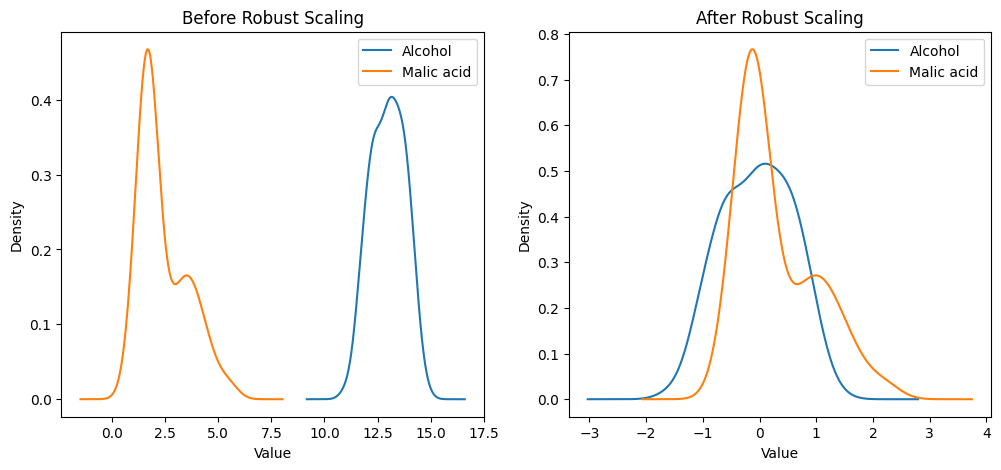

In [109]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before Robust Scaling
X_train[['Alcohol', 'Malic acid']].plot(
    kind='kde',
    ax=ax1
)
ax1.set_title("Before Robust Scaling")
ax1.set_xlabel("Value")

# After Robust Scaling
X_train_scaled[['Alcohol', 'Malic acid']].plot(
    kind='kde',
    ax=ax2
)
ax2.set_title("After Robust Scaling")
ax2.set_xlabel("Value")

plt.show()

## c. Scatter

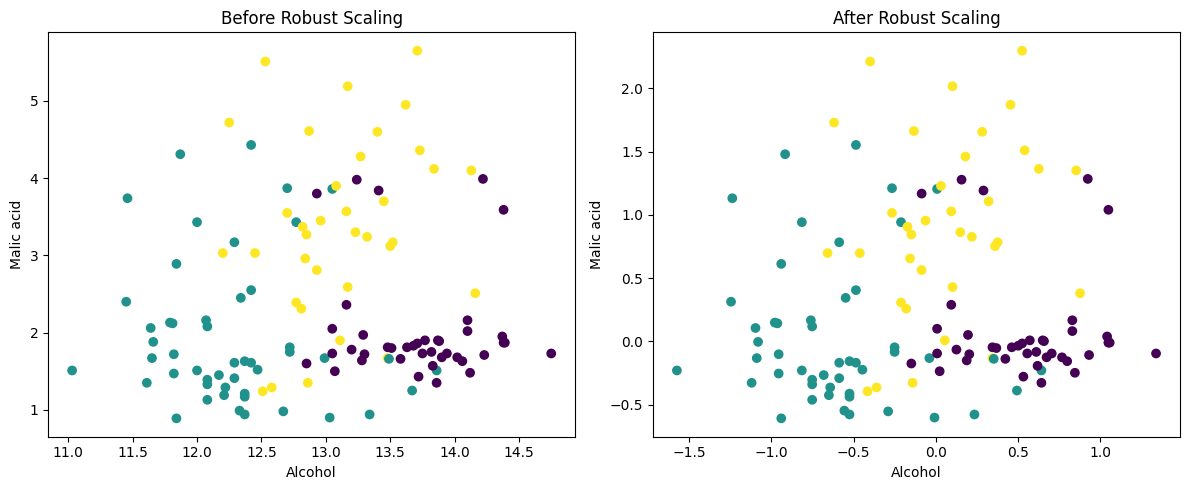

In [110]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Before
ax1.scatter(
    X_train['Alcohol'],
    X_train['Malic acid'],
    c=y_train
)
ax1.set_title("Before Robust Scaling")
ax1.set_xlabel("Alcohol")
ax1.set_ylabel("Malic acid")

# After
ax2.scatter(
    X_train_scaled['Alcohol'],
    X_train_scaled['Malic acid'],
    c=y_train
)
ax2.set_title("After Robust Scaling")
ax2.set_xlabel("Alcohol")
ax2.set_ylabel("Malic acid")

plt.tight_layout()
plt.show()